# Netflix Content Recommendation System

### Auspify Technologies - Machine Learning Internship
### Task 1

This project implements a content-based recommendation system
to recommend similar Netflix titles based on their content attributes.

Author: B S Vanisha Babu

## Introduction

This project implements a content-based recommendation system for Netflix titles. The system recommends titles that are similar to a selected title based on content-related features such as type, director, country, rating, and genre information.

TF-IDF is used to convert the combined text features into numerical representations, and cosine similarity is used to identify similar titles.

In [ ]:
import pandas as pd
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Saving Dataset.csv to Dataset (1).csv
Dataset loaded successfully!
Shape: (8790, 10)


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [ ]:
print("Dataset Information:")
print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB
None

Column Names:
['show_id', 'type', 'title', 'director', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in']

Missing Values:
show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0


In [ ]:
features = ['type', 'director', 'country', 'rating', 'listed_in']

print("Selected features:")
for feature in features:
    print("-", feature)

Selected features:
- type
- director
- country
- rating
- listed_in


In [ ]:
content_df = df[features].copy()

content_df.head()

,type,director,country,rating,listed_in
0,Movie,Kirsten Johnson,United States,PG-13,Documentaries
1,TV Show,Julien Leclercq,France,TV-MA,"Crime TV Shows, International TV Shows, TV Act..."
2,TV Show,Mike Flanagan,United States,TV-MA,"TV Dramas, TV Horror, TV Mysteries"
3,Movie,Bruno Garotti,Brazil,TV-PG,"Children & Family Movies, Comedies"
4,Movie,Haile Gerima,United States,TV-MA,"Dramas, Independent Movies, International Movies"


In [ ]:
# Combine the selected features into one text column

content_df['combined_features'] = (
    content_df['type'] + ' ' +
    content_df['director'] + ' ' +
    content_df['country'] + ' ' +
    content_df['rating'] + ' ' +
    content_df['listed_in']
)

content_df[['combined_features']].head()

,combined_features
0,Movie Kirsten Johnson United States PG-13 Docu...
1,TV Show Julien Leclercq France TV-MA Crime TV ...
2,TV Show Mike Flanagan United States TV-MA TV D...
3,Movie Bruno Garotti Brazil TV-PG Children & Fa...
4,"Movie Haile Gerima United States TV-MA Dramas,..."


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

print("TF-IDF Vectorizer imported successfully!")

TF-IDF Vectorizer imported successfully!


In [ ]:
# Create the TF-IDF vectorizer

tfidf = TfidfVectorizer(stop_words='english')

# Convert combined features into numerical vectors
tfidf_matrix = tfidf.fit_transform(content_df['combined_features'])

print("TF-IDF matrix created successfully!")
print("Matrix shape:", tfidf_matrix.shape)

TF-IDF matrix created successfully!
Matrix shape: (8790, 6569)


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Calculate similarity between all Netflix titles
similarity_matrix = cosine_similarity(tfidf_matrix)

print("Cosine similarity matrix created successfully!")
print("Matrix shape:", similarity_matrix.shape)

Cosine similarity matrix created successfully!
Matrix shape: (8790, 8790)


In [ ]:
def recommend_titles(title, num_recommendations=10):

    # Find the index of the selected title
    title_index = df[df['title'].str.lower() == title.lower()].index

    if len(title_index) == 0:
        print("Title not found in the dataset.")
        return

    index = title_index[0]

    # Get similarity scores for the selected title
    similarity_scores = list(enumerate(similarity_matrix[index]))

    # Sort titles by similarity score
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    # Get the top recommendations
    recommendations = similarity_scores[1:num_recommendations + 1]

    print(f"Recommendations for: {df.iloc[index]['title']}")
    print()

    for i, score in recommendations:
        print(f"{df.iloc[i]['title']} - Similarity Score: {score:.3f}")

In [ ]:
recommend_titles("Midnight Mass")

Recommendations for: Midnight Mass

Gerald's Game - Similarity Score: 0.802
Hush - Similarity Score: 0.753
Before I Wake - Similarity Score: 0.703
Brand New Cherry Flavor - Similarity Score: 0.670
The Haunting of Bly Manor - Similarity Score: 0.670
Ratched - Similarity Score: 0.670
The Haunting of Hill House - Similarity Score: 0.670
The Originals - Similarity Score: 0.637
American Horror Story - Similarity Score: 0.616
Hannibal - Similarity Score: 0.616


In [ ]:
recommend_titles("The Witcher")

Recommendations for: The Witcher

The Witcher - Similarity Score: 1.000
The Liberator - Similarity Score: 0.936
Marco Polo - Similarity Score: 0.936
Spartacus - Similarity Score: 0.936
Outlander - Similarity Score: 0.927
Bard of Blood - Similarity Score: 0.903
Queen of the South - Similarity Score: 0.902
Altered Carbon - Similarity Score: 0.902
Marvel's Jessica Jones - Similarity Score: 0.902
Marvel's Iron Fist - Similarity Score: 0.902


In [ ]:
recommend_titles("Stranger Things")

Recommendations for: Stranger Things

Stranger Things - Similarity Score: 1.000
Nightflyers - Similarity Score: 0.968
Helix - Similarity Score: 0.968
Manifest - Similarity Score: 0.934
The Vampire Diaries - Similarity Score: 0.934
The 4400 - Similarity Score: 0.934
The Messengers - Similarity Score: 0.934
The OA - Similarity Score: 0.900
The Umbrella Academy - Similarity Score: 0.886
Warrior Nun - Similarity Score: 0.854


In [ ]:
def evaluate_recommendations(title, num_recommendations=5):

    title_index = df[df['title'].str.lower() == title.lower()].index

    if len(title_index) == 0:
        print("Title not found in the dataset.")
        return

    index = title_index[0]

    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = similarity_scores[1:num_recommendations + 1]

    print(f"Evaluation for: {df.iloc[index]['title']}")
    print("-" * 50)

    total_score = 0

    for i, score in recommendations:
        print(f"{df.iloc[i]['title']} -> {score:.3f}")
        total_score += score

    average_score = total_score / num_recommendations

    print("-" * 50)
    print(f"Average similarity score: {average_score:.3f}")

In [ ]:
evaluate_recommendations("Midnight Mass")

Evaluation for: Midnight Mass
--------------------------------------------------
Gerald's Game -> 0.802
Hush -> 0.753
Before I Wake -> 0.703
Brand New Cherry Flavor -> 0.670
The Haunting of Bly Manor -> 0.670
--------------------------------------------------
Average similarity score: 0.720


In [ ]:
import pandas as pd

def recommendation_table(title, num_recommendations=10):

    title_index = df[df['title'].str.lower() == title.lower()].index

    if len(title_index) == 0:
        print("Title not found in the dataset.")
        return

    index = title_index[0]

    similarity_scores = list(enumerate(similarity_matrix[index]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = similarity_scores[1:num_recommendations + 1]

    results = []

    for i, score in recommendations:
        results.append({
            'Recommended Title': df.iloc[i]['title'],
            'Type': df.iloc[i]['type'],
            'Genre': df.iloc[i]['listed_in'],
            'Similarity Score': round(score, 3)
        })

    return pd.DataFrame(results)

In [ ]:
recommendation_table("Midnight Mass")

,Recommended Title,Type,Genre,Similarity Score
0,Gerald's Game,Movie,"Horror Movies, Thrillers",0.802
1,Hush,Movie,"Horror Movies, Thrillers",0.753
2,Before I Wake,Movie,"Horror Movies, Thrillers",0.703
3,Brand New Cherry Flavor,TV Show,"TV Dramas, TV Horror, TV Mysteries",0.670
4,The Haunting of Bly Manor,TV Show,"TV Dramas, TV Horror, TV Mysteries",0.670
5,Ratched,TV Show,"TV Dramas, TV Horror, TV Mysteries",0.670
6,The Haunting of Hill House,TV Show,"TV Dramas, TV Horror, TV Mysteries",0.670
7,The Originals,TV Show,"TV Dramas, TV Horror, TV Mysteries",0.637
8,American Horror Story,TV Show,"TV Horror, TV Mysteries, TV Thrillers",0.616
9,Hannibal,TV Show,"TV Horror, TV Mysteries, TV Thrillers",0.616


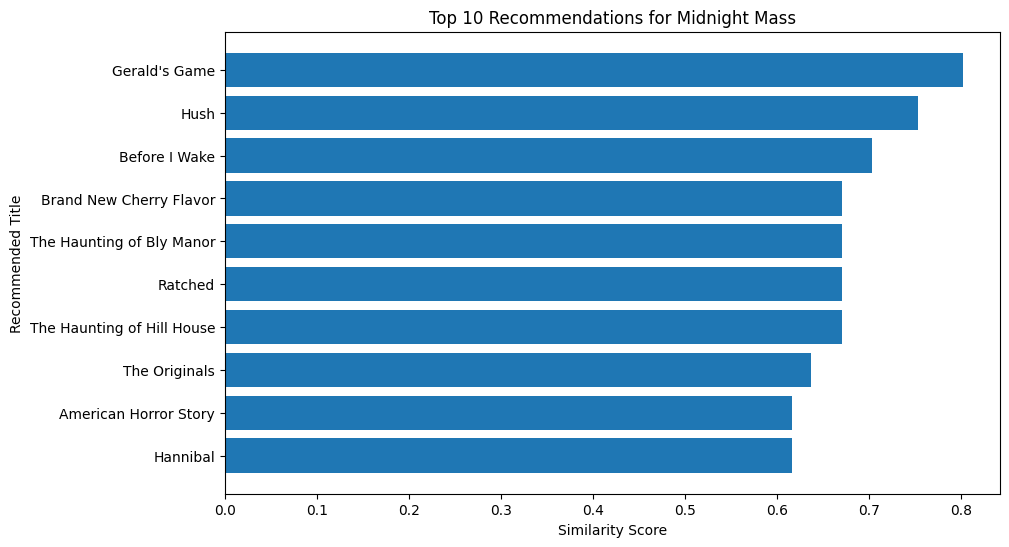

In [ ]:
import matplotlib.pyplot as plt

results = recommendation_table("Midnight Mass")

plt.figure(figsize=(10, 6))

plt.barh(
    results['Recommended Title'],
    results['Similarity Score']
)

plt.xlabel("Similarity Score")
plt.ylabel("Recommended Title")
plt.title("Top 10 Recommendations for Midnight Mass")
plt.gca().invert_yaxis()

plt.show()

In [ ]:
recommendation_table("The Witcher", 5)

,Recommended Title,Type,Genre,Similarity Score
0,The Witcher,TV Show,"International TV Shows, TV Action & Adventure,...",1.000
1,The Liberator,TV Show,"TV Action & Adventure, TV Dramas",0.936
2,Marco Polo,TV Show,"TV Action & Adventure, TV Dramas",0.936
3,Spartacus,TV Show,"TV Action & Adventure, TV Dramas",0.936
4,Outlander,TV Show,"Romantic TV Shows, TV Action & Adventure, TV D...",0.927


In [ ]:
recommendation_table("Stranger Things", 5)

,Recommended Title,Type,Genre,Similarity Score
0,Stranger Things,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",1.000
1,Nightflyers,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",0.968
2,Helix,TV Show,"TV Horror, TV Mysteries, TV Sci-Fi & Fantasy",0.968
3,Manifest,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.934
4,The Vampire Diaries,TV Show,"TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy",0.934


## Conclusion

A content-based Netflix recommendation system was successfully developed using Python and machine learning techniques.

The system uses content-related attributes such as type, director, country, rating, and genre information from the Netflix dataset. These features were combined and converted into numerical representations using TF-IDF. Cosine similarity was then used to measure the similarity between Netflix titles.

The recommendation function can take a Netflix title as input and generate a list of similar titles based on their content features.

The results show that the system is able to identify titles with similar content characteristics and provide relevant recommendations. The system can be further improved by including additional information such as descriptions, cast, keywords, user ratings, and viewing history.

## Project Workflow

1. Load the Netflix dataset
2. Inspect the dataset and check for missing values
3. Select relevant content features
4. Combine the selected features
5. Convert text features into numerical vectors using TF-IDF
6. Calculate cosine similarity between titles
7. Create a recommendation function
8. Test the recommendation system with different Netflix titles
9. Evaluate recommendations using similarity scores
10. Visualize the recommendation results

## Technologies Used

- Python
- Pandas
- Scikit-learn
- Matplotlib
- Google Colab
- TF-IDF
- Cosine Similarity